In [ ]:
# 1. Import libraries
# 2. Read Data file CSV
# 3. Clean up data ->
#    -> check null values percentage
#    -> drop rows which have Nan or NA
#    -> rows which are float  with .0, convert them to int64 to get rid of .0
#    -> 2 columns have year info, ensure they have same year values, convert from obj to str, then split and get year
#        -> Then year is in str data type, so convert to numeric and coerce
#   
# 4. Check for revenue outliers using boxplot
# 5. Correlation between columns
#    -> Using Seaborn Regplot
#    -> Seeing correlation matrix in table for for all 3 methods (pearson,kendall,spearman)
#    -> Seeing correlation matrix in a plot using seaborn heatmap
# 6. EDA - top 15 companies based on revenue, and other stuff with year company and revenue
# 7. Plots 
#    -> Scatter plot
#    -> Strip plot

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

pd.options.mode.chained_assignment = None


In [2]:
# 2. Read and look at the data

df = pd.read_csv(r"C:\Users\Meghna\OneDrive\Documents\Data_Analytics\MySQL\Portfolio Project-MySql Server Mgmt Studio\movies.csv")
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [3]:
# 3. Cleaning up the data

# 3a. Check if there is missing data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [4]:
for col in df.columns:
    percent_missing = np.mean(df[col].isnull())
    #print(col, percent_missing) # can just do this as well but for better formatting, use below 
    print('{} - {}%'.format(col, percent_missing))

name - 0.0%
rating - 0.010041731872717789%
genre - 0.0%
year - 0.0%
released - 0.0002608242044861763%
score - 0.0003912363067292645%
votes - 0.0003912363067292645%
director - 0.0%
writer - 0.0003912363067292645%
star - 0.00013041210224308815%
country - 0.0003912363067292645%
budget - 0.2831246739697444%
gross - 0.02464788732394366%
company - 0.002217005738132499%
runtime - 0.0005216484089723526%


In [5]:
# 3b. Drop all rows with missing data for now
df = df.dropna()

In [6]:
# 3c. get rid of .0 in gross and budget column

df['budget'] = df['budget'].astype('int64') 
df['gross'] = df['gross'].astype('int64')
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344,Orion Pictures,98.0


In [ ]:
# To look at all the data
# pd.set_option('display.max.rows', None)

In [7]:
# 3d. There are 2 columns year and released, which have year info, but both should be same and they aren't
# Check the actual CSV in excel
# Create a new column by taking the year from released column

df['year'] = df['released'].astype('str').str.split().str[2]
df['year']

0       1980
1       1980
2       1980
3       1980
4       1980
        ... 
7648    2020
7649    2020
7650    2020
7651    2020
7652    2020
Name: year, Length: 5421, dtype: object

In [9]:
# Found that year column had rows with non-numeric values
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna()
df['year'] = df['year'].astype(int)
df['year']


0       1980
1       1980
2       1980
3       1980
4       1980
        ... 
7648    2020
7649    2020
7650    2020
7651    2020
7652    2020
Name: year, Length: 5407, dtype: int64

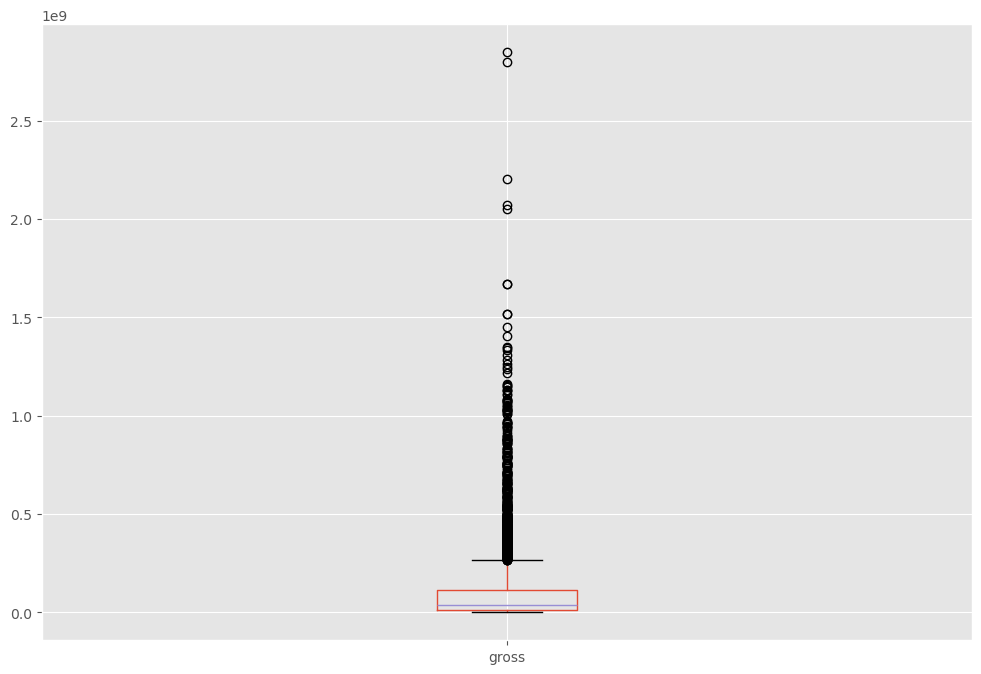

In [10]:
# 4. Check for revenue outliers using boxplot

df.boxplot(column=['gross'])
plt.show()

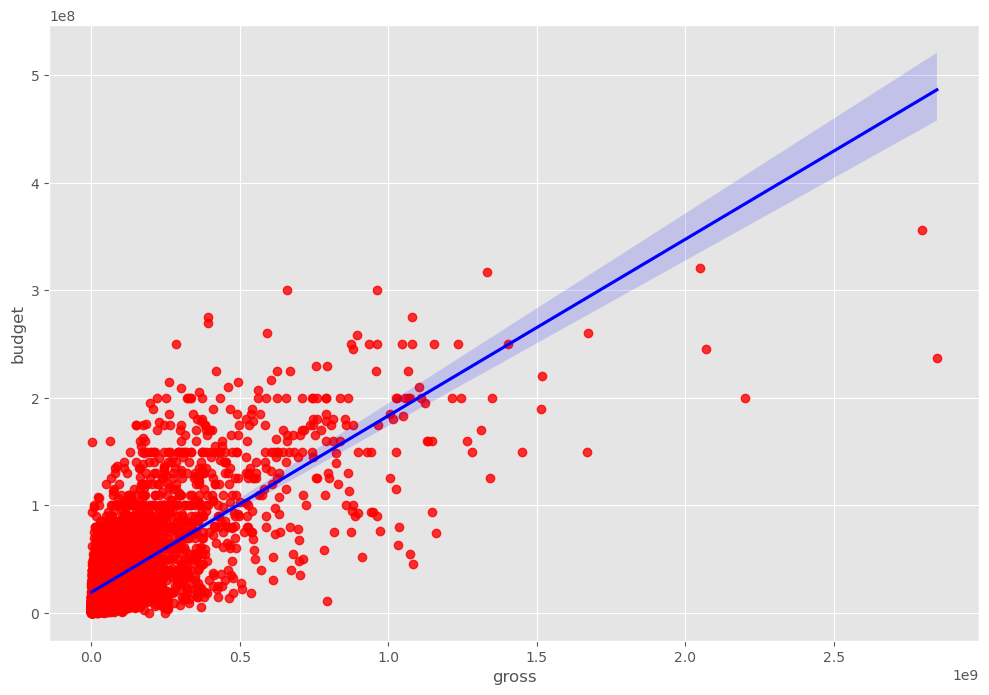

In [11]:
# 5a. Correlation between columns usind regplot
sns.regplot(x="gross", y="budget", data=df, scatter_kws={'color':'red'}, line_kws={'color':'blue'})
plt.show()

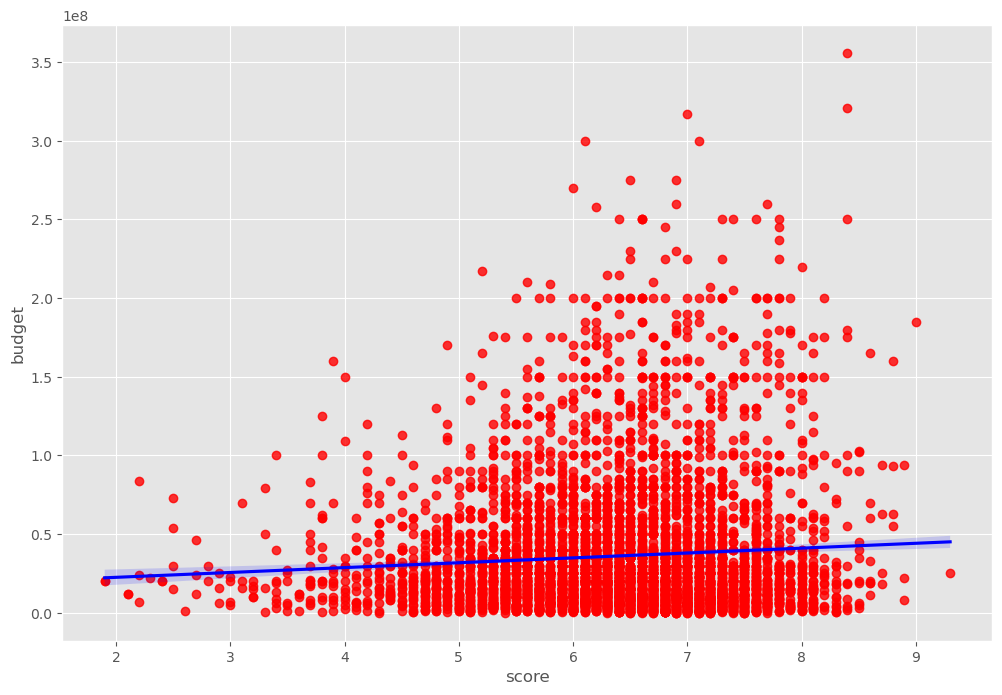

In [12]:
sns.regplot(x="score", y="budget", data=df, scatter_kws={'color':'red'}, line_kws={'color':'blue'})
plt.show()

In [13]:
# 5b. Correlation Matrix in table form between all numeric columns
df.corr(numeric_only=True, method='pearson')

,year,score,votes,budget,gross,runtime
year,1.000000,0.061443,0.202215,0.319669,0.268141,0.075183
score,0.061443,1.000000,0.474594,0.071552,0.222504,0.414501
votes,0.202215,0.474594,1.000000,0.439077,0.614432,0.352263
budget,0.319669,0.071552,0.439077,1.000000,0.740028,0.318353
gross,0.268141,0.222504,0.614432,0.740028,1.000000,0.275641
runtime,0.075183,0.414501,0.352263,0.318353,0.275641,1.000000


In [14]:
df.corr(numeric_only=True, method='kendall')

,year,score,votes,budget,gross,runtime
year,1.000000,0.043315,0.291619,0.212905,0.231100,0.064861
score,0.043315,1.000000,0.350695,-0.007075,0.124601,0.292696
votes,0.291619,0.350695,1.000000,0.344894,0.552331,0.205562
budget,0.212905,-0.007075,0.344894,1.000000,0.510889,0.230709
gross,0.231100,0.124601,0.552331,0.510889,1.000000,0.176728
runtime,0.064861,0.292696,0.205562,0.230709,0.176728,1.000000


In [15]:
df.corr(numeric_only=True, method='spearman')

,year,score,votes,budget,gross,runtime
year,1.000000,0.063547,0.421171,0.301319,0.338824,0.095559
score,0.063547,1.000000,0.496104,-0.010972,0.182673,0.412782
votes,0.421171,0.496104,1.000000,0.491603,0.744457,0.300912
budget,0.301319,-0.010972,0.491603,1.000000,0.691660,0.330007
gross,0.338824,0.182673,0.744457,0.691660,1.000000,0.257024
runtime,0.095559,0.412782,0.300912,0.330007,0.257024,1.000000


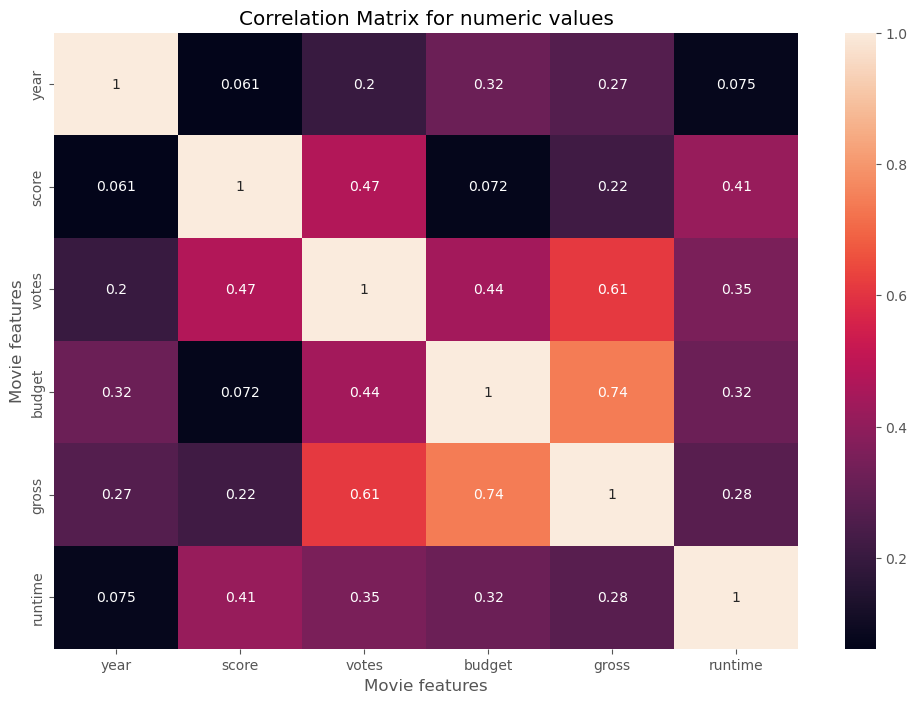

In [16]:
# 5c. Correlation matrix visual for numeric values
corrmat = df.corr(numeric_only=True) # default corr method is pearson
sns.heatmap(corrmat, annot = True)
plt.title("Correlation Matrix for numeric values")
plt.xlabel("Movie features")
plt.ylabel("Movie features")
plt.show()

# shows that budget and gross are positively correlated

In [17]:
# 6a. Get top 15 companies by revenue

companytotalgross = df.groupby('company')['gross'].sum() 
companytotalgrosssorted = companytotalgross.sort_values(ascending = False).head(15) 
companytotalgrosssorted

company
Warner Bros.                 54610959970
Universal Pictures           51241105418
Columbia Pictures            42356430218
Paramount Pictures           40021704691
Twentieth Century Fox        39541625997
Walt Disney Pictures         35833650748
New Line Cinema              19612851164
Marvel Studios               15065592411
DreamWorks Animation         11873612858
Dreamworks Pictures          11593807697
Touchstone Pictures          10664679494
Metro-Goldwyn-Mayer (MGM)     8936980277
Summit Entertainment          8318570396
Pixar Animation Studios       7886344526
Fox 2000 Pictures             7243673721
Name: gross, dtype: int64

In [19]:
# 6b. Check the sum of gross for each company for each year and sort
companyyeartotalgross = df.groupby(['company','year'])[['gross']].sum()
companyyeartotalgross_sorted = companyyeartotalgross.sort_values(by=['gross','company','year'],ascending = [False,True,False]).head(15)
companyyeartotalgross_sorted

,,gross
company,year,
Walt Disney Pictures,2019,5773131804
Marvel Studios,2018,4018631866
Universal Pictures,2015,3834354888
Twentieth Century Fox,2009,3793491246
Walt Disney Pictures,2017,3789382071
Paramount Pictures,2011,3565705182
Warner Bros.,2011,3168551343
Walt Disney Pictures,2010,3104474158
Paramount Pictures,2014,3071298586


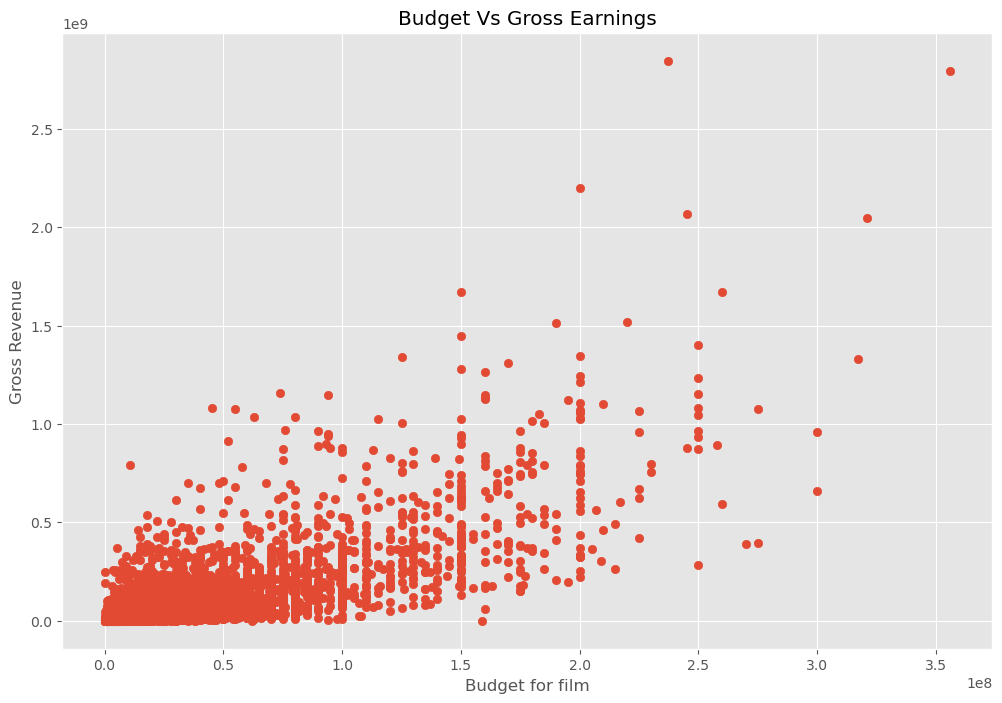

In [20]:
# 7. Scatter plot of budget vs gross

plt.scatter(x=df['budget'], y=df['gross'])
plt.title('Budget Vs Gross Earnings')
plt.xlabel('Budget for film')
plt.ylabel('Gross Revenue')
plt.show()

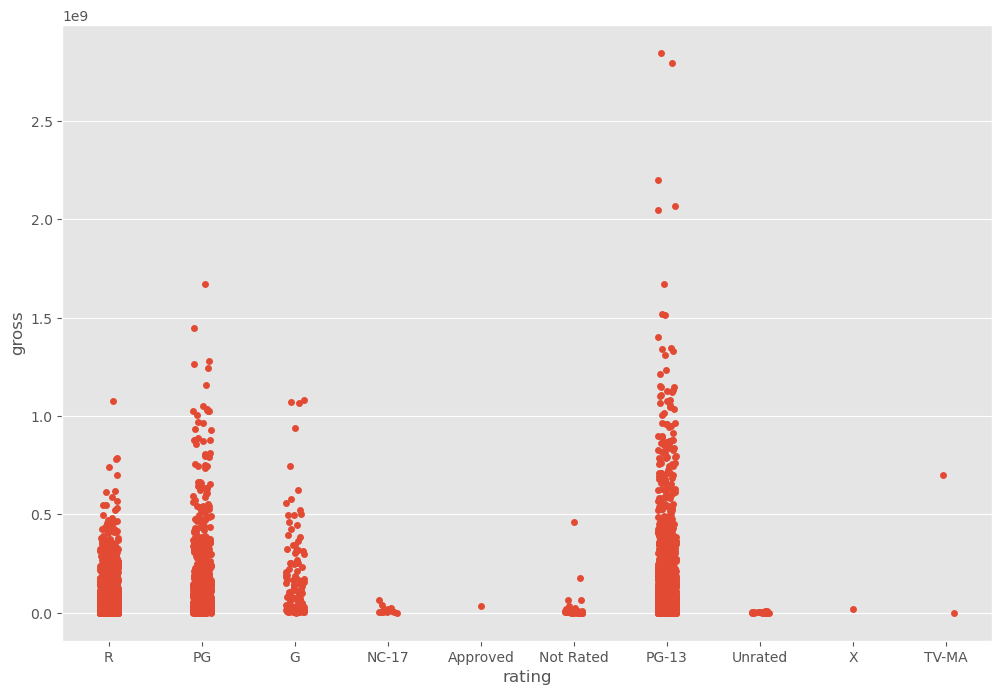

In [23]:
# 8. Strip plot
sns.stripplot(x="rating", y="gross", data=df)
plt.show()